# Pazy wing flutter analysis

Evaluate the aeroelastic eigenvalues (and resulting frequency and damping) for key modes for the Pazy wing. This gives data that matches well with the literature. This takes approximately 22 minutes to run for all three AoA cases on an M2 MacBook Air (this can be reduced by changing ``n_vel`` as well as altering the discretisation).

Imports

In [1]:
from copy import deepcopy
from functools import partial

from matplotlib import pyplot as plt
from pathlib import Path

import jax
from jax import numpy as jnp, Array

from aegrad.aero.flowfields import Constant
from aegrad.coupled import CoupledAeroelastic
from aegrad.utils.print_utils import VerbosityLevel, set_verbosity
from models.pazy.straight.pazy_wing import make_pazy_wing

Discretisation and Parameter Setup

In [2]:
jax.config.update("jax_enable_x64", True)  # 64 bit precision is required for flutter analysis
set_verbosity(VerbosityLevel.SILENT)  # remove AEGrad console prints due to the large number of cases

n_vel = 48  # number of velocity points
m = 12  # wing chordwise discretisation
m_star = 50  # number of wake panels per strip
alphas = jnp.deg2rad(jnp.array((3.0, 5.0, 7.0)))  # angle of attack
u_inf_mags = jnp.linspace(20.0, 65.0, n_vel)  # velocity sweep

# plot directory
out_dir = Path("plots")
out_dir.mkdir(parents=True, exist_ok=True)

# plot colourmap
cmap = plt.get_cmap("viridis")
norm = plt.Normalize(vmin=float(u_inf_mags.min()), vmax=float(u_inf_mags.max()))

Factory for the base wing at a given AoA. Shared across all velocities within a case.

In [3]:
def make_wing(alpha: float | Array):
    return make_pazy_wing(
        flowfield=Constant(
            u_inf=jnp.array([0.0, 0.0, 0.0]),
            rho=1.225,
            relative_motion=True,
        ),
        aoa=alpha,
        m=m,
        m_star=m_star,
        node_multiplier=2,
        skin=True,
        variable_disc_wake=True,
        sweep=0.0,
    )

Function to evaluate the eigenvalues for a given wing and velocity. This is mapped across the input velocities, allowing multiple design points to be evaluated in parallel.

In [4]:
def eigs_at_velocity(u_mag: Array, wing: CoupledAeroelastic) -> Array:
    # this function is mapped across the input velocities, allowing multiple design points to be evaluated in
    # parallel
    inner_wing = deepcopy(wing)

    # set the required design variables for this case
    dt = 0.1 / (m * u_mag)
    inner_wing.set_design_variables(
        coords=inner_wing.structure.x0,
        k_cs=inner_wing.structure.k_cs,
        m_cs=inner_wing.structure.m_cs,
        m_lumped=None,
        dt=dt,
        flowfield=Constant(
            u_inf=jnp.array([u_mag, 0.0, 0.0]),
            rho=1.225,
            relative_motion=True,
        ),
        x0_aero=inner_wing.aero.x0_b,
        remove_checks=True,
    )

    # obtain static equilibrium
    static_sol = inner_wing.static_solve(
        prescribed_dofs=tuple(range(6)),
        horseshoe=False,
    )
    # linearise solution about static equilibrium
    linear_sol = inner_wing.linearise(
        reference=static_sol, skip_checks=True, batch_size=64, n_struct_modes=20
    )
    # obtain eigenvalies of linearised system
    eigvals = linear_sol.modal(
        n_modes=5,
        plot_eigvals=False,
        freq_range=(0.0, 50.0),
        damp_range=(-0.3, 0.3),
    )
    return eigvals

Approximate flutter onset and offset points by interpolating for where the damping is zero.

In [5]:
def flutter_points(min_zeta: Array) -> tuple[float | None, float | None]:
    # interpolate to approximate flutter onset/offset for the hump mode (first two crossings)
    crossover_point = jnp.sign(min_zeta[1:]) != jnp.sign(min_zeta[:-1])
    crossing_indices = jnp.where(crossover_point)[0]

    def interp_zero(idx: int) -> float:
        # linearly interpolate between positive and negative damping points to find velocity where it would be zero
        z0, z1 = float(min_zeta[idx]), float(min_zeta[idx + 1])
        u0, u1 = float(u_inf_mags[idx]), float(u_inf_mags[idx + 1])
        return u0 + (0.0 - z0) / (z1 - z0) * (u1 - u0)

    u_onset = interp_zero(int(crossing_indices[0])) if crossing_indices.size >= 1 else None
    u_offset = interp_zero(int(crossing_indices[1])) if crossing_indices.size >= 2 else None
    return u_onset, u_offset

Plot eigenvalues for a given AoA, with colour representing velocity.

In [6]:
def plot_eigenvalues(evals: Array, alpha: Array) -> None:
    fig, ax = plt.subplots()
    for i in range(len(u_inf_mags)):
        ax.scatter(
            evals[i].real / (2.0 * jnp.pi),
            evals[i].imag / (2.0 * jnp.pi),
            color=cmap(norm(float(u_inf_mags[i]))),
            s=10,
        )
    ax.set_xlim(-6.0, 2.0)
    ax.set_ylim(0.0, 50.0)
    ax.axvline(0.0, color="k", linewidth=0.5)
    ax.set_xlabel("Re(eig) / (2 * pi) [1/s]")
    ax.set_ylabel("Im(eig) / (2 * pi) [1/s]")
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, ax=ax, label="u_inf [m/s]")
    ax.set_title(f"Pazy wing eigenvalues vs velocity, aoa={float(jnp.rad2deg(alpha)):.1f} deg")
    fig.savefig(out_dir / f"pazy_eigenvalues_aoa={float(jnp.rad2deg(alpha)):.1f}.png")

Plot damping ratio and damped frequency for a given AoA, with colour representing velocity.

In [7]:
def plot_damp_freq(
        zeta: Array,
        freq_d: Array,
        u_onset: float | None,
        u_offset: float | None,
        alpha: Array,
) -> None:
    fig, (ax_z, ax_f) = plt.subplots(1, 2, figsize=(11, 4.5))
    for i in range(len(u_inf_mags)):
        c = cmap(norm(float(u_inf_mags[i])))
        u = float(u_inf_mags[i])
        ax_z.scatter(jnp.full_like(zeta[i], u), -zeta[i], color=c, s=10)
        ax_f.scatter(jnp.full_like(freq_d[i], u), freq_d[i], color=c, s=10)

    ax_z.axhline(0.0, color="k", linewidth=0.5)
    if u_onset is not None:
        ax_z.axvline(
            u_onset,
            color="r",
            linewidth=0.8,
            linestyle="--",
            label=f"onset = {u_onset:.1f} m/s",
        )
    if u_offset is not None:
        ax_z.axvline(
            u_offset,
            color="b",
            linewidth=0.8,
            linestyle="--",
            label=f"offset = {u_offset:.1f} m/s",
        )
    if u_onset is not None or u_offset is not None:
        ax_z.legend(loc="lower right", fontsize=8)
    ax_z.set_xlabel("u_inf [m/s]")
    ax_z.set_ylabel("-Damping ratio")
    ax_z.set_xlim(u_inf_mags.min(), u_inf_mags.max())
    ax_z.set_ylim(-0.1, 0.1)
    ax_z.set_title(f"Damping ratio, aoa={float(jnp.rad2deg(alpha)):.1f} deg")

    ax_f.set_xlabel("u_inf [m/s]")
    ax_f.set_ylabel("Damped frequency f_d [Hz]")
    ax_f.set_xlim(u_inf_mags.min(), u_inf_mags.max())
    ax_f.set_ylim(0.0, 50.0)
    ax_f.set_title(f"Damped frequency, aoa={float(jnp.rad2deg(alpha)):.1f} deg")
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, ax=(ax_z, ax_f), label="u_inf [m/s]")

    fig.savefig(out_dir / f"pazy_damp_freq_aoa={float(jnp.rad2deg(alpha)):.1f}.png")

Evaluate the model by mapping the eigenvalue function across the velocity sweep for each AoA case.

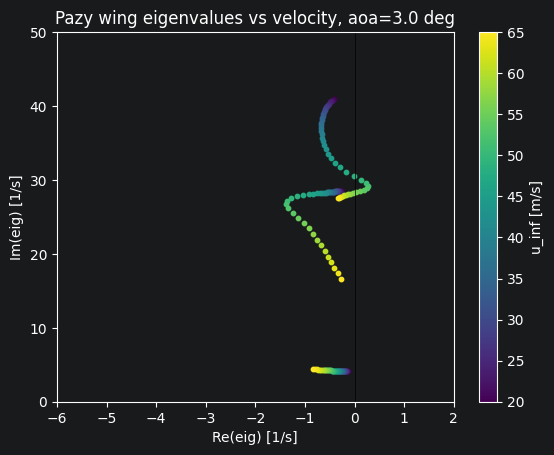

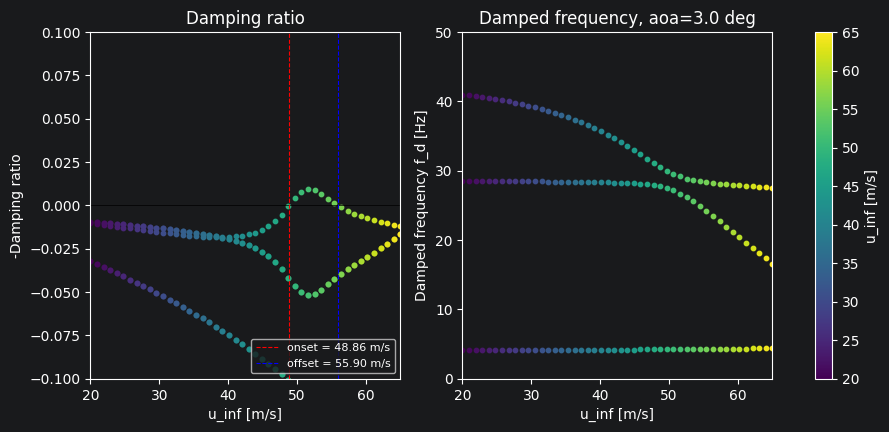

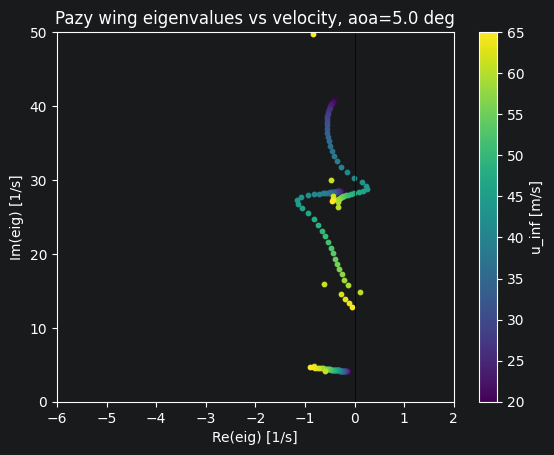

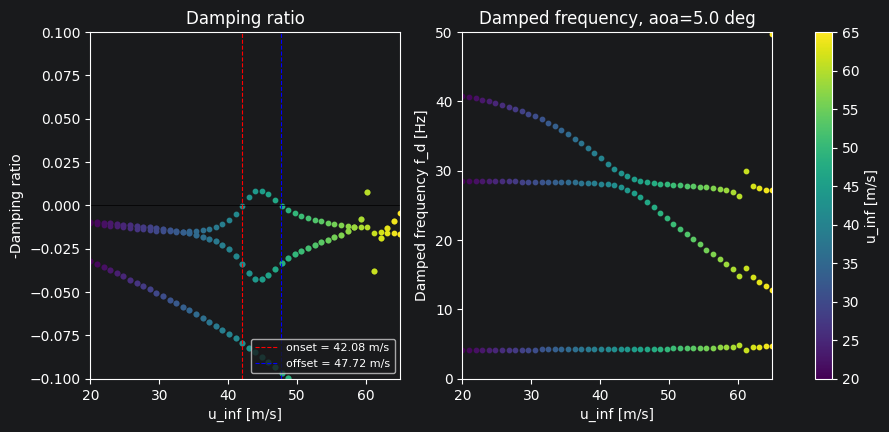

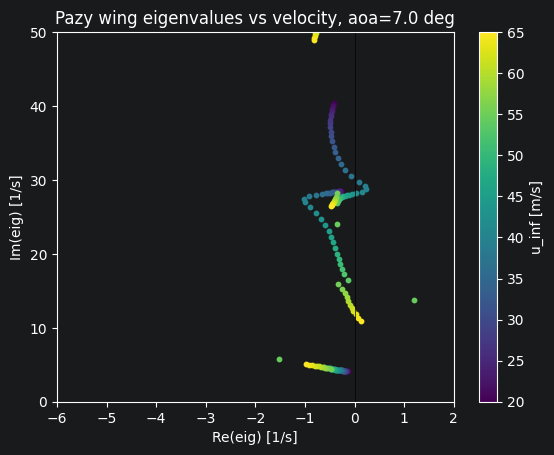

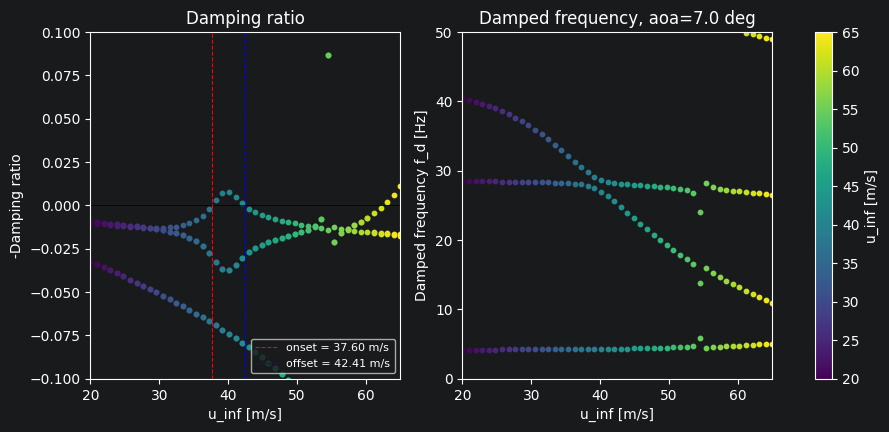

In [8]:
for alpha_ in alphas:  # AoA sweep
    wing_ = make_wing(alpha=alpha_)

    # evaluate eigenvalues
    evals_ = jax.lax.map(partial(eigs_at_velocity, wing=wing_), u_inf_mags, batch_size=4)  # [n_vel, n_modes]

    zeta_ = -evals_.real / jnp.abs(evals_)  # damping ratio [n_vel, n_modes]
    freq_d_ = evals_.imag / (2.0 * jnp.pi)  # damped frequency (Hz), [n_vel, n_modes]

    min_zeta_ = zeta_.min(axis=1)  # minimum damping [n_vel]
    u_onset_, u_offset_ = flutter_points(min_zeta=min_zeta_)  # flutter onset and offset velocity

    plot_eigenvalues(evals=evals_, alpha=alpha_)
    plot_damp_freq(zeta=zeta_, freq_d=freq_d_, u_onset=u_onset_, u_offset=u_offset_, alpha=alpha_)

    plt.show()